In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive')

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model=YOLO('yolov8n.pt')
results=model('https://ultralytics.com/images/bus.jpg')
from IPython.display import Image
display(Image('result.jpg'))


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 7.0ms
Speed: 2.3ms preprocess, 7.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


FileNotFoundError: No such file or directory: 'result.jpg'

FileNotFoundError: No such file or directory: 'result.jpg'

<IPython.core.display.Image object>

In [ ]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/bus.jpg' save=True

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 81.2ms
Speed: 7.1ms preprocess, 81.2ms inference, 22.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


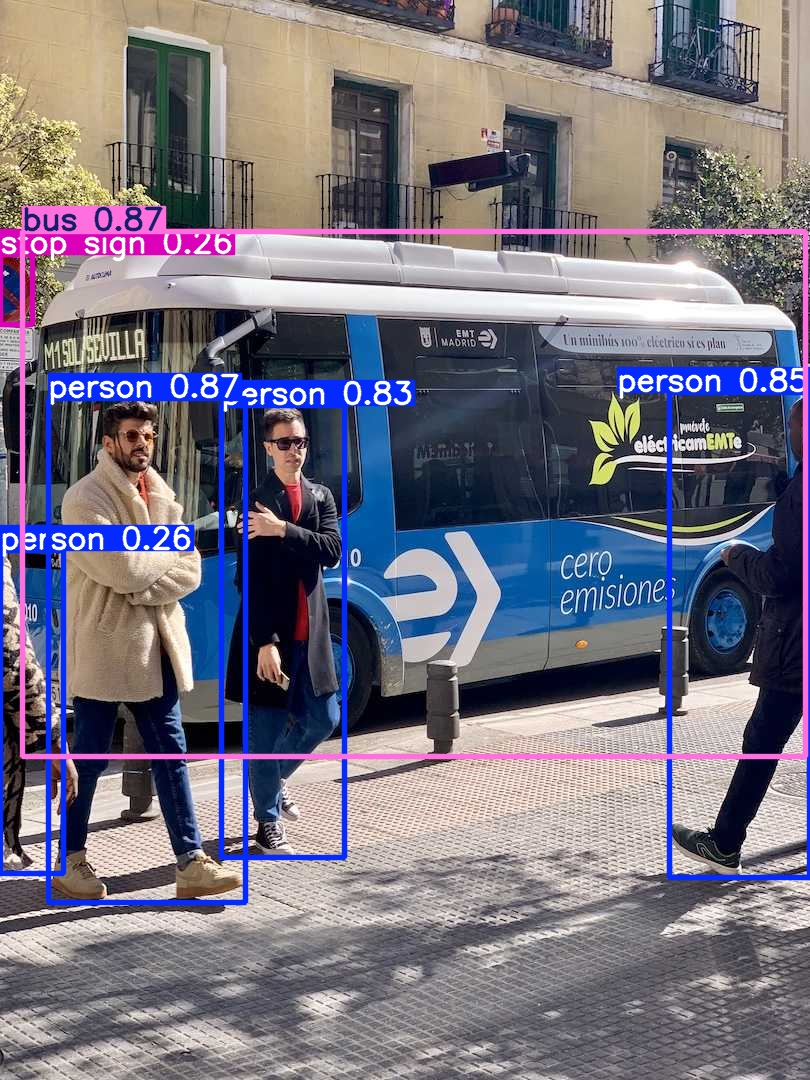

In [ ]:
from IPython.display import Image, display
display(Image('runs/detect/predict/bus.jpg'))

In [ ]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/videos/highway.mp4' save=True

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Download failure, retrying 1/3 https://ultralytics.com/videos/highway.mp4... HTTP Error 404: Not Found
######################################################################## 100.0%
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x270da340] moov atom not found
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 1080, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 541, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^

In [ ]:
from IPython.display import Video, display
display(Video('runs/detect/predict/highway.mp4', width=720,embed=True))

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

model = YOLO('yolov8n.pt')

# 读取视频
cap = cv2.VideoCapture('https://ultralytics.com/videos/highway.mp4')

# 获取视频信息
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 定义视频编码器
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('result_video.mp4', fourcc, fps, (width, height))

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret or frame_count > 100:  # 只处理前100帧，不然太久
        break

    # 检测
    results = model(frame)

    # 画框
    annotated_frame = results[0].plot()

    # 写入输出视频
    out.write(annotated_frame)

    frame_count += 1

cap.release()
out.release()

print(f"处理完成！共处理{frame_count}帧")

处理完成！共处理0帧


In [ ]:
from google.colab import files
files.download('result_video.mp4')

FileNotFoundError: Cannot find file: result_video.mp4

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 微信视频2026-07-07_204337_928.mp4 to 微信视频2026-07-07_204337_928.mp4


In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2
from google.colab import files

model = YOLO('yolov8n.pt')

# 上传你的孤独摇滚视频
uploaded = files.upload()
video_name = list(uploaded.keys())[0]
print(f"正在处理：{video_name}")

cap = cv2.VideoCapture(video_name)
if not cap.isOpened():
    print("❌ 打不开，换个方法...")
else:
    # 只读第10帧、第30帧、第50帧看看
    for frame_num in [10, 30, 50]:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if ret:
            results = model(frame)
            print(f"第{frame_num}帧：检测到{len(results[0].boxes)}个目标")
            for box in results[0].boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                name = model.names[cls]
                print(f"  - {name}: {conf:.2f}")
            cv2_imshow(results[0].plot())

cap.release()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

model = YOLO('yolov8n.pt')

# 直接用你的视频文件名
video_name = '微信视频2026-07-07_204337_928.mp4'

cap = cv2.VideoCapture(video_name)

# 获取视频参数
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"视频：{w}x{h}, {fps}fps, 共{total}帧")

# 处理全部帧
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('孤独摇滚_检测结果.mp4', fourcc, fps, (w, h))

count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame)
    out.write(results[0].plot())
    count += 1
    if count % 50 == 0:
        print(f"已处理 {count}/{total} 帧")

cap.release()
out.release()
print(f"✅ 全部完成！共处理{count}帧")

# 下载到电脑

视频：1440x1080, 30fps, 共1436帧

0: 480x640 1 person, 8.7ms
Speed: 3.3ms preprocess, 8.7ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.8ms
Speed: 2.8ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 7.4ms
Speed: 3.8ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 clock, 7.8ms
Speed: 3.7ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 clock, 10.3ms
Speed: 3.4ms preprocess, 10.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 6.4ms
Speed: 4.2ms preprocess, 6.4ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 8.3ms
Speed: 3.4ms preprocess, 8.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 8.8ms
Speed: 3.9ms preprocess, 8.8ms inference, 1.4ms postproc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 先装 ffmpeg
!apt-get install ffmpeg -q

# 把原视频的声音合到检测后的视频上
!ffmpeg -i 孤独摇滚_检测结果.mp4 -i 微信视频2026-07-07_204337_928.mp4 -c:v copy -c:a aac -map 0:v:0 -map 1:a:0 孤独摇滚_最终版.mp4 -y -loglevel error

print("✅ 声音合成完成！")

# 下载最终版
from google.colab import files
files.download('孤独摇滚_最终版.mp4')

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
✅ 声音合成完成！


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
import os

kaggle_info = {
    "username": "Routinere",
    "key": "KGAT_0d9450eda436da98a0b9d448b1626de3"
}

# 保存为文件
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_info, f)

!chmod 600 /root/.kaggle/kaggle.json

# 验证是否成功
!kaggle datasets list

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset        4154062  2026-06-10 12:58:47.093000           9083        221                1  
uditjain13/social-media-screen-time-and-mental-health-2026      Social Media, Screen Time & Mental Health 2026         178487  2026-07-05 09:19:11.450000            575         24                1  
arjunmehta1992/chocolate-sales-in-20222023                      Chocolate Sales in 2022–2023                          4820417  2026-06-21 03:52:16.600000           3278         46                1  
sunil

In [ ]:
# 下载 WildFire-Smoke-Dataset-Yolo
!kaggle datasets download -d ahemateja19bec1025/wildfiresmokedatasetyolo

# 解压
!unzip -q wildfiresmokedatasetyolo.zip -d wildfire_smoke_data

# 看看里面有什么
import os
print("数据集内容：")
for root, dirs, files in os.walk('wildfire_smoke_data'):
    depth = root.replace('wildfire_smoke_data', '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:15]:
        print(f"{indent}  {f}")
    if depth > 2:
        break

Dataset URL: https://www.kaggle.com/datasets/ahemateja19bec1025/wildfiresmokedatasetyolo
License(s): CC0-1.0
100% 27.2M/27.2M [00:00<00:00, 78.6MB/s]

数据集内容：
wildfire_smoke_data/
  labels_WildFire_Smoke.csv
  WildFire_Smoke_Dataset_YOLO/
    data.yaml
    valid/
      images/
        ck0l8drn7ahtr08388pnkoq7o_jpeg.rf.8d2ca8e98935e95bc0eb1140b6af2b7b.jpg
        ck0lxh38zu5ri0848ra81j7ne_jpeg.rf.053a40bc4b01c6b1919eba1c31519126.jpg
        ck0ujob3n85zc0a46r0pdmhoy_jpeg.rf.6afc92c99814d4f4d59f7b1784507dd5.jpg
        ck0nf44ililfz0a469cimeiu1_jpeg.rf.7e434bcb0feeb390e756630dcc84add0.jpg
        ck0nculry62mq0944n824zvzk_jpeg.rf.de8abeaa0043fe7af64f470b761f71ee.jpg
        ck0u0m0dqtaz70838kcm0o9w3_jpeg.rf.18bc37d578299e69072fb85c71c3c445.jpg
        ck0nfq2hsj1ro0a46o4gncg6r_jpeg.rf.cf37f869ea810dc8beaa5a20ee1810ba.jpg
        ck0t30z1wlpg60838dc6e4lcx_jpeg.rf.d04e3521ec190c980d01cdf80d00183d.jpg
        ck0lxe157jywu0721jwuvnom0_jpeg.rf.5f5a4544cf28c60b90604ee45df40f53.jpg
        ck0n

In [ ]:
import os

data_dir = 'wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO'

# 看看整体结构
for root, dirs, files in os.walk(data_dir):
    depth = root.replace(data_dir, '').count(os.sep)
    indent = '  ' * depth
    folder_name = os.path.basename(root)
    print(f"{indent}{folder_name}/ ({len(files)}个文件)")

print("\n" + "="*50)
print("数据集组成：")

# 统计 train/valid 的图片和标签数量
for split in ['train', 'valid']:
    img_dir = f"{data_dir}/{split}/images"
    label_dir = f"{data_dir}/{split}/labels"
    if os.path.exists(img_dir):
        imgs = os.listdir(img_dir)
        print(f"{split}/images: {len(imgs)}张图片")
    if os.path.exists(label_dir):
        labels = os.listdir(label_dir)
        print(f"{split}/labels: {len(labels)}个标注文件")

# 看看 data.yaml
with open(f"{data_dir}/data.yaml", 'r') as f:
    print("\ndata.yaml 内容：")
    print(f.read())

WildFire_Smoke_Dataset_YOLO/ (1个文件)
  valid/ (0个文件)
    images/ (147个文件)
    labels/ (147个文件)
  test/ (0个文件)
    images/ (74个文件)
    labels/ (74个文件)
  train/ (0个文件)
    images/ (516个文件)
    labels/ (516个文件)

数据集组成：
train/images: 516张图片
train/labels: 516个标注文件
valid/images: 147张图片
valid/labels: 147个标注文件

data.yaml 内容：
train: ../train/images
val: ../valid/images

nc: 1
names: ['smoke']


In [ ]:
# ===== 第一步：装 YOLOv8 =====
!pip install ultralytics -q

# ===== 第二步：配置 Kaggle API =====
import json, os

kaggle_info = {
    "username": "Routinere",
    "key": "KGAT_0d9450eda436da98a0b9d448b1626de3"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_info, f)
!chmod 600 /root/.kaggle/kaggle.json

# ===== 第三步：下载第一个数据集 =====
!kaggle datasets download -d ahemateja19bec1025/wildfiresmokedatasetyolo
!unzip -q wildfiresmokedatasetyolo.zip -d wildfire_smoke_data

# ===== 第四步：确认文件存在 =====
import os
print("data.yaml 是否存在：", os.path.exists('/content/wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/data.yaml'))

# ===== 第五步：开始训练 =====
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='/content/wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device='cuda',
    project='forest_fire_project',
    name='smoke_detection',
    exist_ok=True,
)

Dataset URL: https://www.kaggle.com/datasets/ahemateja19bec1025/wildfiresmokedatasetyolo
License(s): CC0-1.0
100% 27.2M/27.2M [00:02<00:00, 11.4MB/s]

data.yaml 是否存在： True
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fc477fc56a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import os

# 搜所有包含 forest 的文件夹
for root, dirs, files in os.walk('/content'):
    if 'forest' in root.lower():
        print(f"📁 {root}")
        for f in files[:5]:
            print(f"   📄 {f}")

📁 /content/runs/detect/forest_fire_project
📁 /content/runs/detect/forest_fire_project/smoke_detection
   📄 train_batch2.jpg
   📄 BoxPR_curve.png
   📄 train_batch0.jpg
   📄 val_batch0_labels.jpg
   📄 val_batch2_labels.jpg
📁 /content/runs/detect/forest_fire_project/smoke_detection/weights
   📄 best.pt
   📄 last.pt


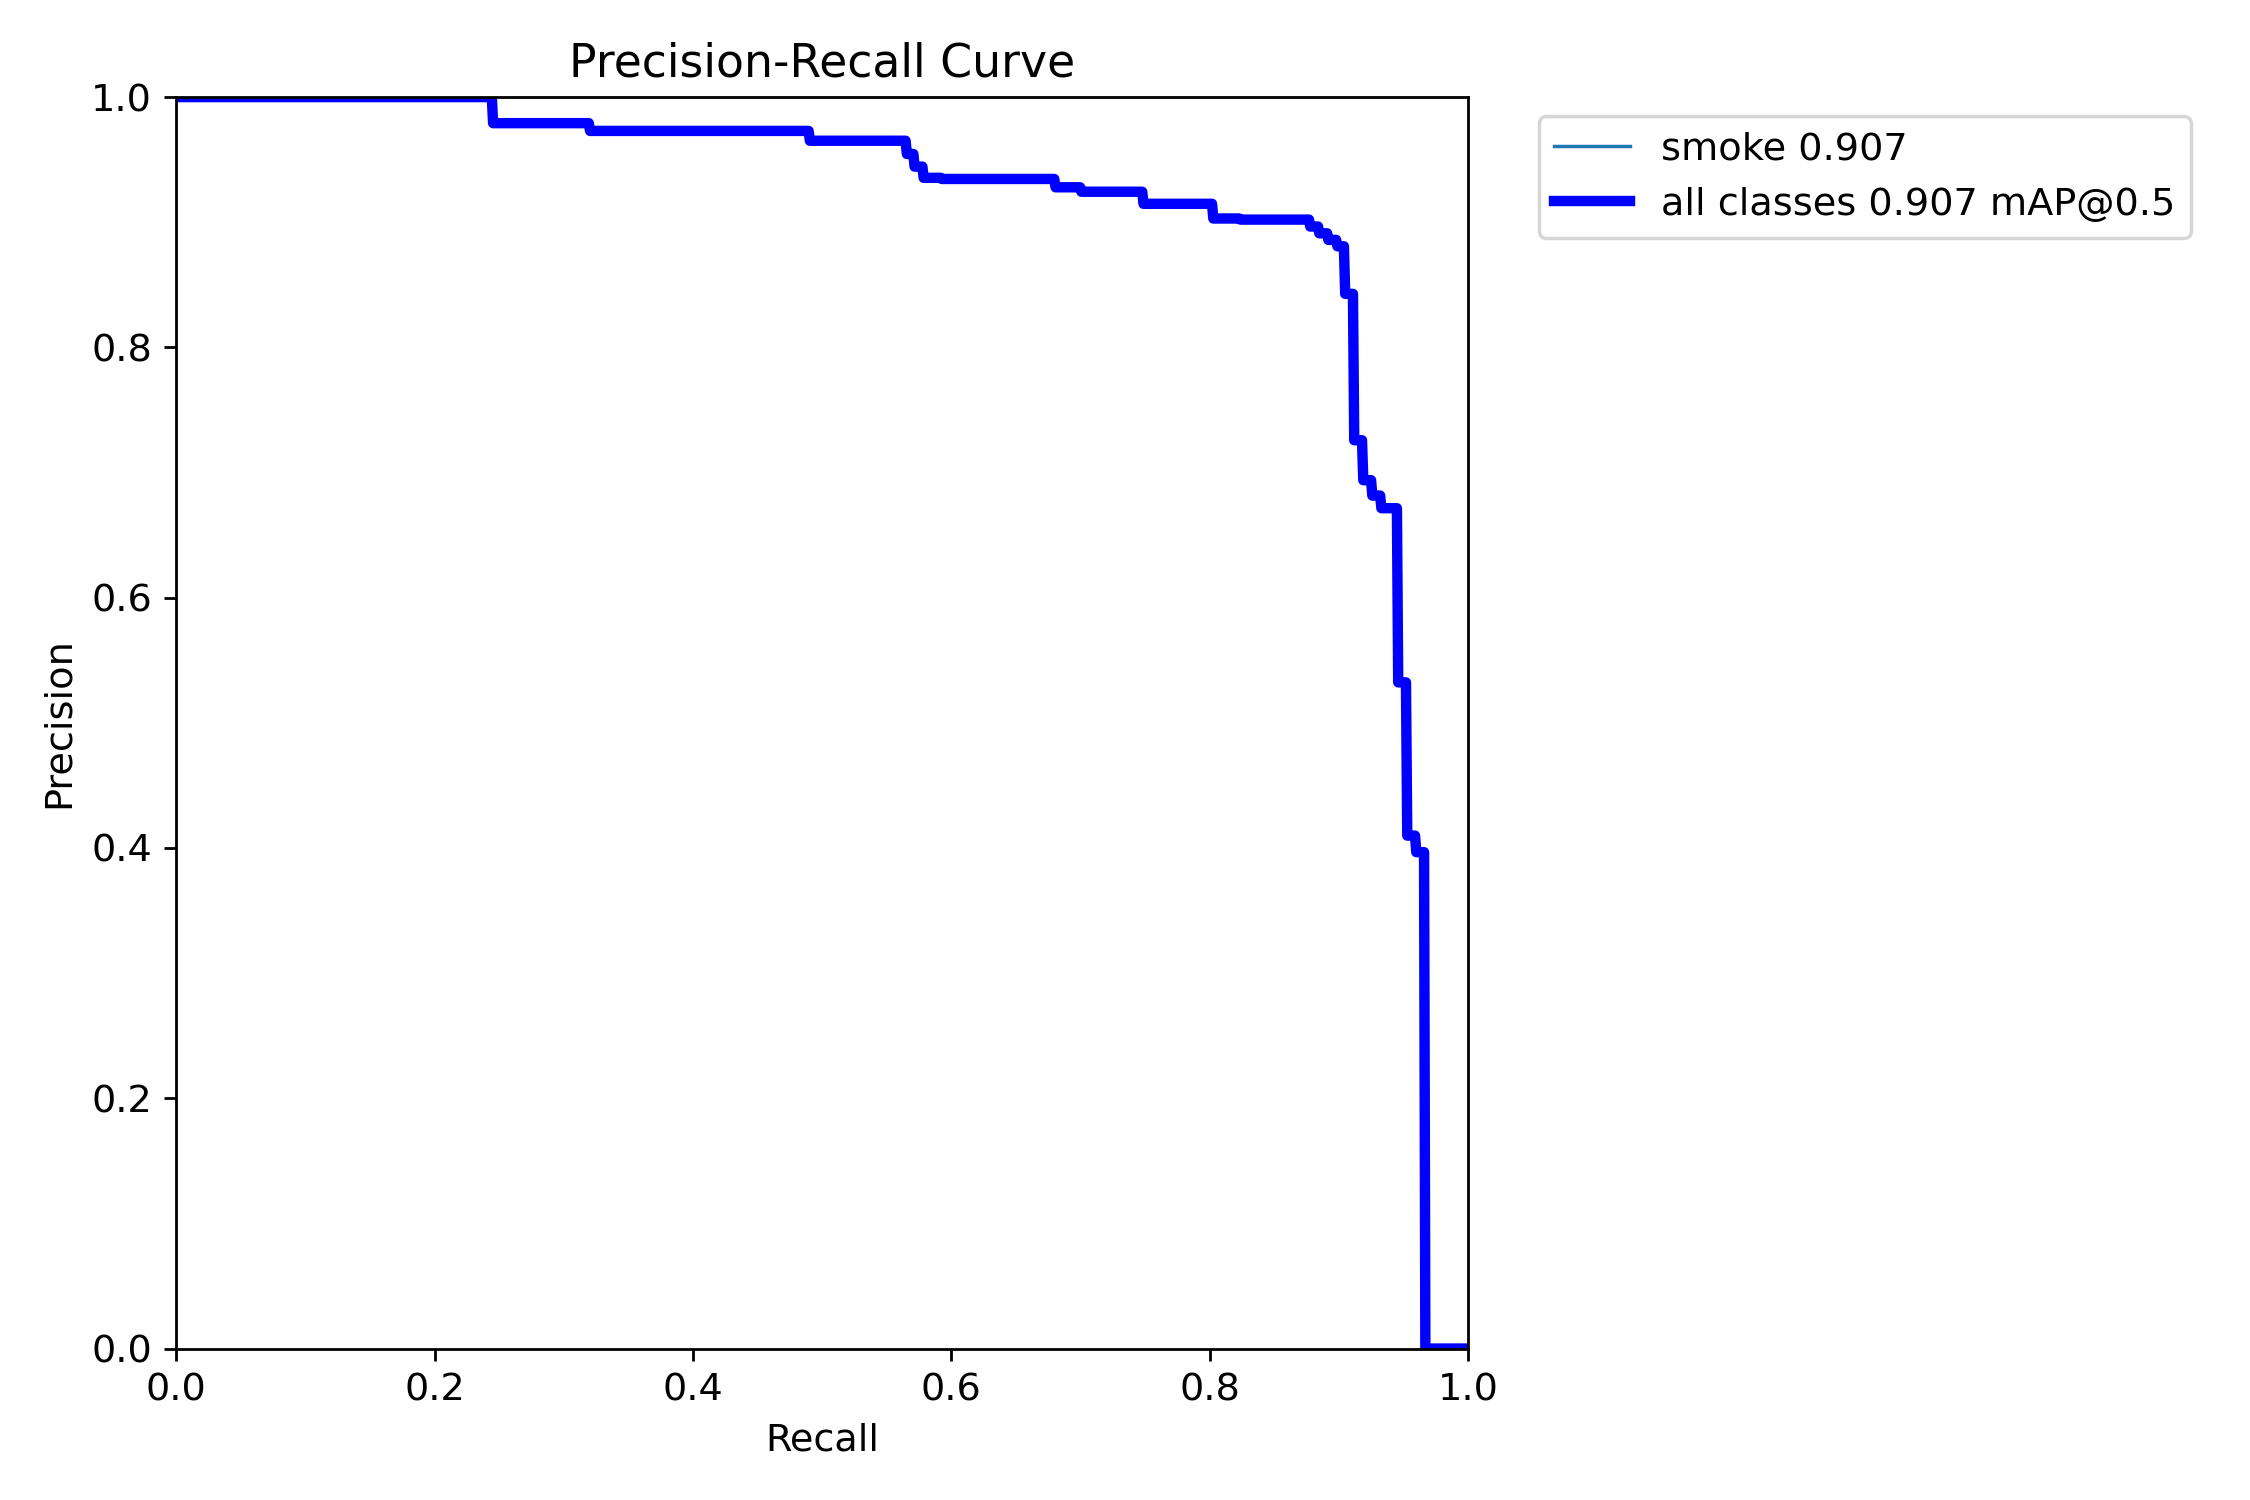

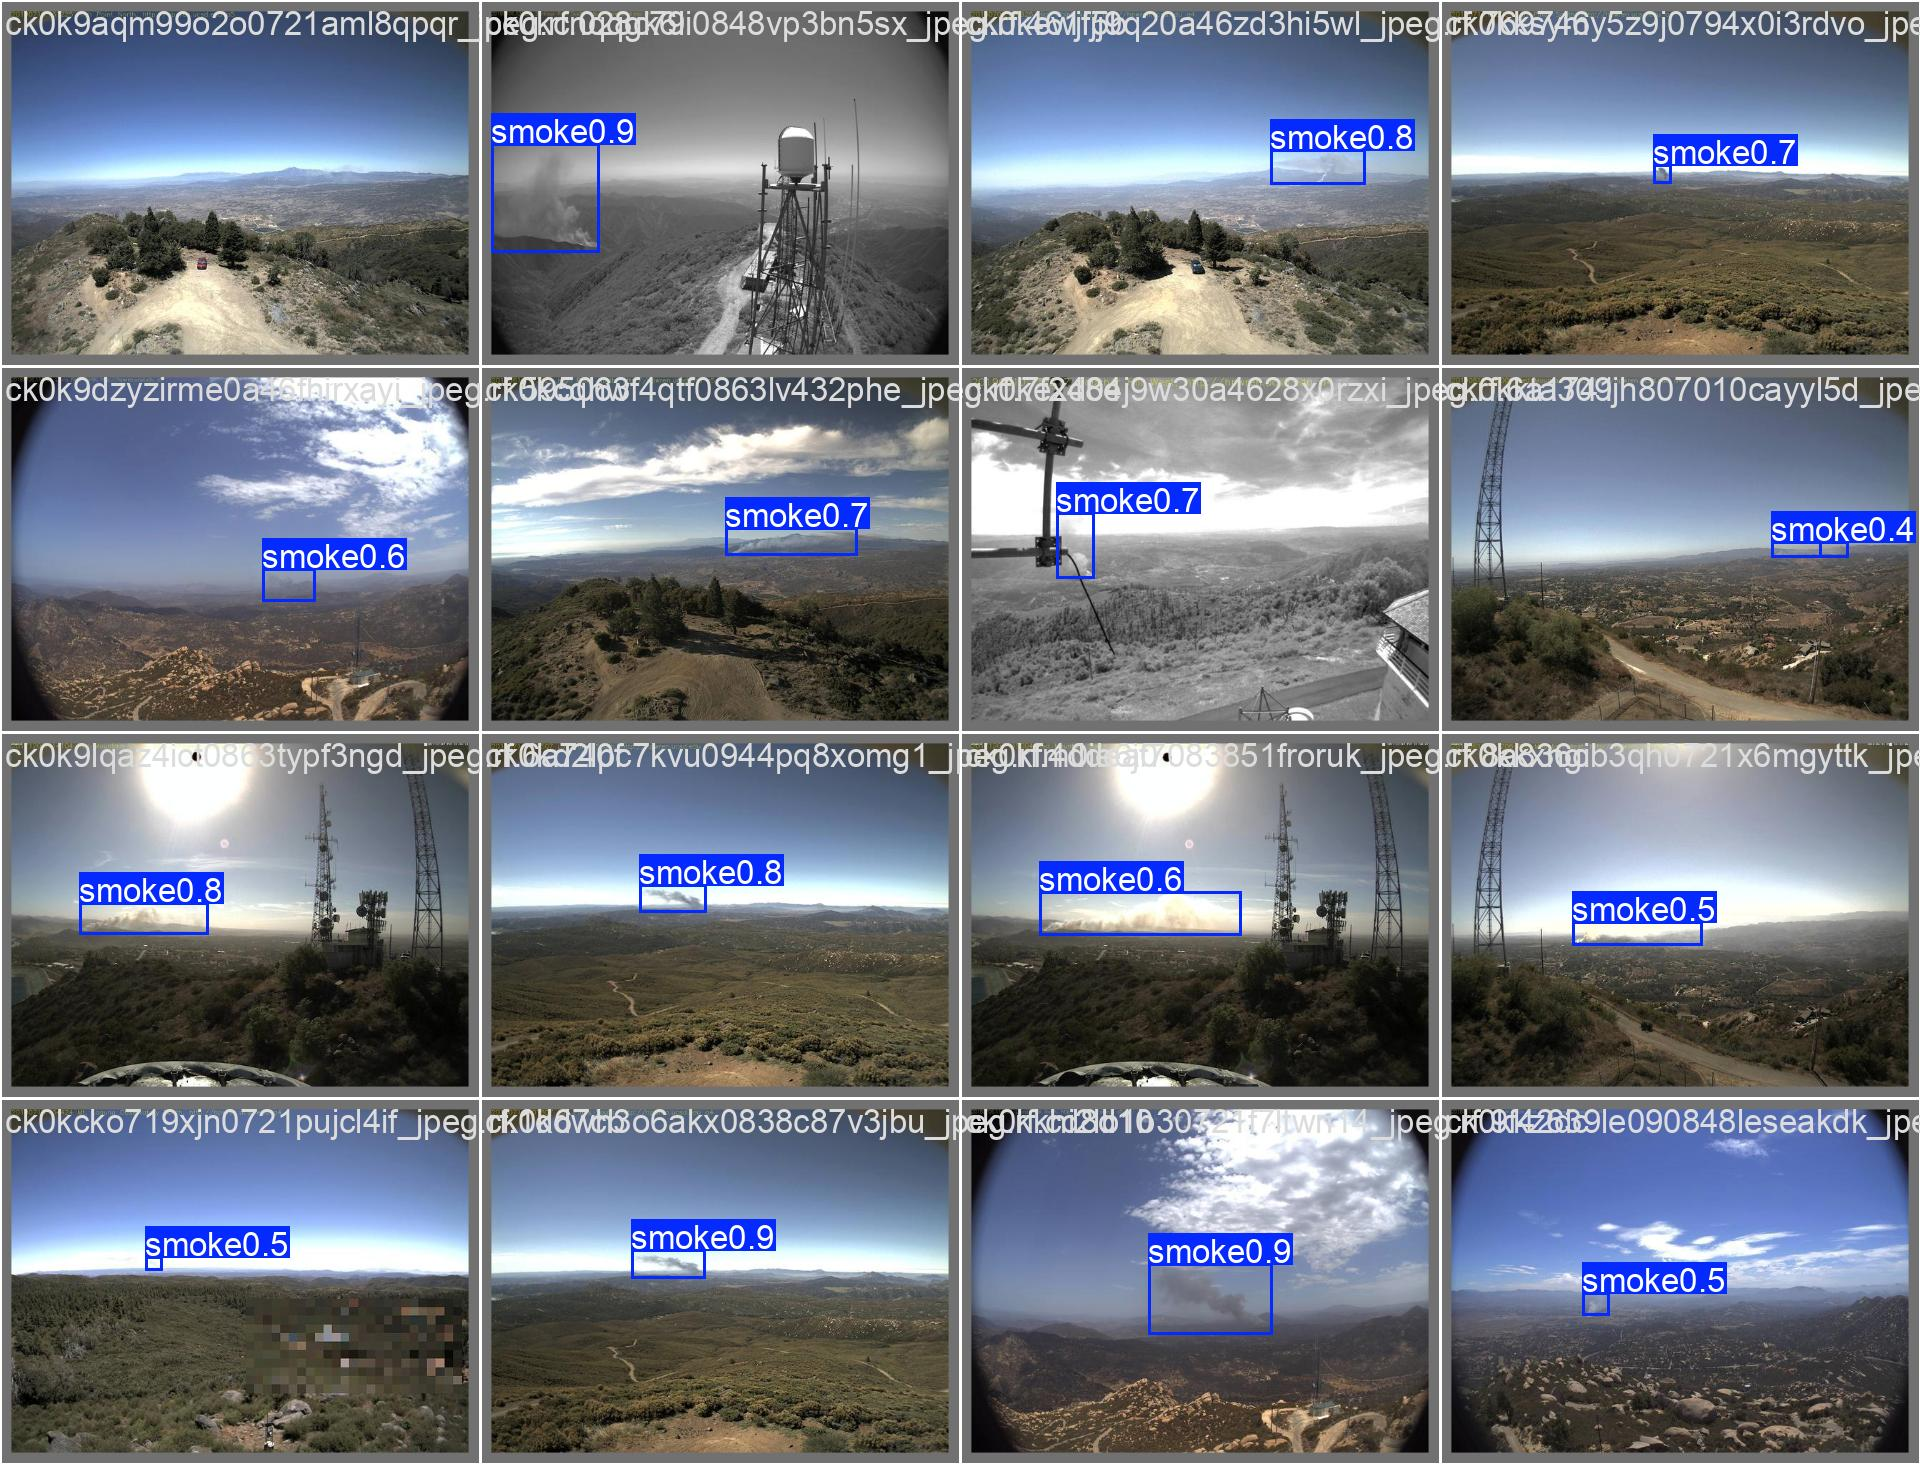

In [ ]:
from IPython.display import Image, display

# 训练指标
display(Image('/content/runs/detect/forest_fire_project/smoke_detection/BoxPR_curve.png'))

# 验证集预测效果
display(Image('/content/runs/detect/forest_fire_project/smoke_detection/val_batch0_pred.jpg'))

In [ ]:
# 下载 Forest Fire by KUTAY KUTLU
!kaggle datasets download -d kutaykutlu/forest-fire

# 解压
!unzip -q forest-fire.zip -d forest_fire_data_kutlu

# 看看结构
import os
for root, dirs, files in os.walk('forest_fire_data_kutlu'):
    depth = root.replace('forest_fire_data_kutlu', '').count(os.sep)
    if depth <= 2:
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/ ({len(files)}个文件)")

Dataset URL: https://www.kaggle.com/datasets/kutaykutlu/forest-fire
License(s): unknown
100% 2.46G/2.46G [02:05<00:00, 21.0MB/s]

forest_fire_data_kutlu/ (0个文件)
  train-smoke/ (12631个文件)
  test_big/ (2007个文件)
  train_fire/ (1102个文件)
  test_small/ (25个文件)


In [ ]:
import os

data_dir = 'forest_fire_data_kutlu'

# 看看每个文件夹里的文件长什么样
for folder in ['train-smoke', 'train_fire', 'test_big', 'test_small']:
    path = f"{data_dir}/{folder}"
    if os.path.exists(path):
        files = os.listdir(path)
        # 看看文件格式
        extensions = set()
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            extensions.add(ext)
        # 看前3个文件名
        print(f"📁 {folder}: {len(files)}个文件")
        print(f"   格式: {extensions}")
        print(f"   示例: {files[:3]}")
        print()

📁 train-smoke: 12631个文件
   格式: {'.jpg', '.png'}
   示例: ['003263.jpg', '007595.jpg', '000250.jpg']

📁 train_fire: 1102个文件
   格式: {'.jpg', '.png'}
   示例: ['fire-9794.14190695.png', '20130611_100618_Black-Forest-Fire-engulfs-house.jpg', 'fire-1183.01476332.png']

📁 test_big: 2007个文件
   格式: {'.jpg'}
   示例: ['000250.jpg', '002124.jpg', '004119.jpg']

📁 test_small: 25个文件
   格式: {'.png'}
   示例: ['fume2.png', 'fire4.png', 'smokeee1.png']




image 1/1 /content/forest_fire_data_kutlu/train_fire/fire-9794.14190695.png: 288x640 (no detections), 44.0ms
Speed: 1.3ms preprocess, 44.0ms inference, 2.5ms postprocess per image at shape (1, 3, 288, 640)
📷 fire-9794.14190695.png: 检测到0个目标


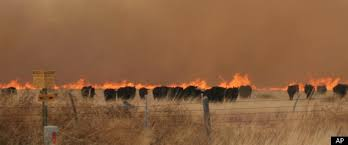


image 1/1 /content/forest_fire_data_kutlu/train_fire/20130611_100618_Black-Forest-Fire-engulfs-house.jpg: 448x640 (no detections), 45.0ms
Speed: 2.8ms preprocess, 45.0ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
📷 20130611_100618_Black-Forest-Fire-engulfs-house.jpg: 检测到0个目标


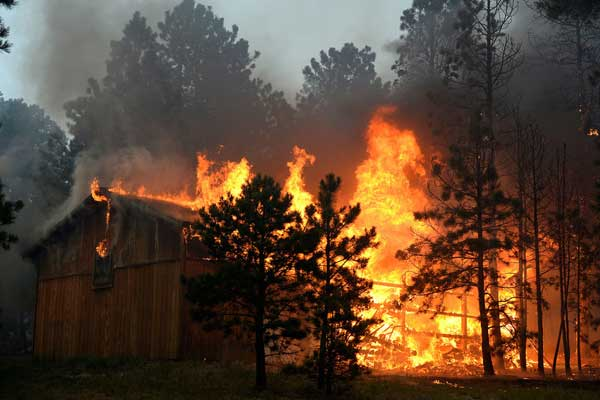


image 1/1 /content/forest_fire_data_kutlu/train_fire/fire-1183.01476332.png: 384x640 (no detections), 61.9ms
Speed: 2.1ms preprocess, 61.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
📷 fire-1183.01476332.png: 检测到0个目标


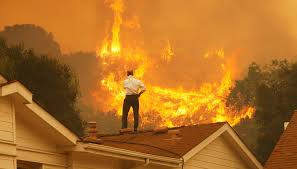


image 1/1 /content/forest_fire_data_kutlu/train_fire/fire-273.504833455.png: 384x640 (no detections), 9.6ms
Speed: 2.3ms preprocess, 9.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
📷 fire-273.504833455.png: 检测到0个目标


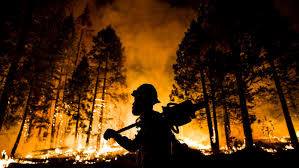


image 1/1 /content/forest_fire_data_kutlu/train_fire/fire-1451.36256326.png: 416x640 (no detections), 56.7ms
Speed: 2.2ms preprocess, 56.7ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)
📷 fire-1451.36256326.png: 检测到0个目标


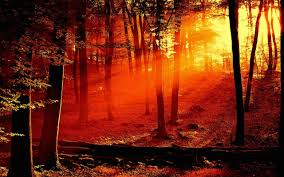

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2
import os

# 加载刚刚训练好的模型
model = YOLO('/content/runs/detect/forest_fire_project/smoke_detection/weights/best.pt')

# 从第二个数据集的 train_fire 里挑几张火焰图片测试
fire_dir = 'forest_fire_data_kutlu/train_fire'
test_files = os.listdir(fire_dir)[:5]  # 先测5张

for fname in test_files:
    img_path = os.path.join(fire_dir, fname)
    results = model(img_path)

    print(f"📷 {fname}: 检测到{len(results[0].boxes)}个目标")
    for box in results[0].boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        name = model.names[cls]
        print(f"   → {name}: {conf:.2f}")

    cv2_imshow(results[0].plot())

In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.4 MB/s eta 0:00:00


In [4]:
# ===== 1. 装 YOLOv8 =====
!pip install ultralytics -q

# ===== 2. 配置 Kaggle API =====
import json, os
kaggle_info = {"username": "Routinere", "key": "KGAT_0d9450eda436da98a0b9d448b1626de3"}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_info, f)
!chmod 600 /root/.kaggle/kaggle.json

# ===== 3. 下载第一个数据集 =====
!kaggle datasets download -d ahemateja19bec1025/wildfiresmokedatasetyolo
!unzip -q wildfiresmokedatasetyolo.zip -d wildfire_smoke_data

# ===== 4. 训练模型 =====
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(
    data='/content/wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device='cuda',
    project='forest_fire_project',
    name='smoke_detection',
    exist_ok=True,
)

Dataset URL: https://www.kaggle.com/datasets/ahemateja19bec1025/wildfiresmokedatasetyolo
License(s): CC0-1.0
100% 27.2M/27.2M [00:02<00:00, 10.4MB/s]

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d67c08cb00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [5]:
# ===== 5. 下载第二个数据集 =====
!kaggle datasets download -d kutaykutlu/forest-fire
!unzip -q forest-fire.zip -d forest_fire_data_kutlu

# ===== 6. 测试烟雾检测 =====
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2, os

model = YOLO('/content/runs/detect/forest_fire_project/smoke_detection/weights/best.pt')

smoke_dir = 'forest_fire_data_kutlu/train-smoke'
test_files = os.listdir(smoke_dir)[:5]

for fname in test_files:
    img_path = os.path.join(smoke_dir, fname)
    results = model(img_path)
    print(f"📷 {fname}: 检测到{len(results[0].boxes)}个目标")
    for box in results[0].boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        name = model.names[cls]
        print(f"   → {name}: {conf:.2f}")
    cv2_imshow(results[0].plot())

Output hidden; open in https://colab.research.google.com to view.

In [6]:
# 用训练好的模型对第二个数据集的烟雾图做自动标注
from ultralytics import YOLO
import cv2, os

model = YOLO('/content/runs/detect/forest_fire_project/smoke_detection/weights/best.pt')

smoke_dir = 'forest_fire_data_kutlu/train-smoke'
output_dir = 'auto_labeled_data'
os.makedirs(f'{output_dir}/images', exist_ok=True)
os.makedirs(f'{output_dir}/labels', exist_ok=True)

# 挑200张检测效果好的，自动生成标注
count = 0
for fname in os.listdir(smoke_dir)[:200]:
    img_path = os.path.join(smoke_dir, fname)
    results = model(img_path)

    if len(results[0].boxes) > 0:  # 只有检测到目标的才保留
        # 复制图片
        !cp "{img_path}" "{output_dir}/images/{fname}"
        # 保存标注
        results[0].save_txt(f'{output_dir}/labels/{os.path.splitext(fname)[0]}.txt')
        count += 1

print(f"自动标注完成：{count}张图")


image 1/1 /content/forest_fire_data_kutlu/train-smoke/005232.jpg: 384x640 (no detections), 12.0ms
Speed: 4.5ms preprocess, 12.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/forest_fire_data_kutlu/train-smoke/005164.jpg: 384x640 1 smoke, 6.8ms
Speed: 2.2ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/forest_fire_data_kutlu/train-smoke/002793.jpg: 384x640 (no detections), 5.8ms
Speed: 1.9ms preprocess, 5.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/forest_fire_data_kutlu/train-smoke/001200.jpg: 384x640 (no detections), 5.6ms
Speed: 1.8ms preprocess, 5.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/forest_fire_data_kutlu/train-smoke/005562.jpg: 384x640 1 smoke, 5.6ms
Speed: 1.7ms preprocess, 5.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/forest_fire_data_kutlu/t

In [7]:
# ===== 1. 合并数据集 =====
import os, shutil

# 创建合并后的数据集目录
merged_dir = 'merged_dataset'
os.makedirs(f'{merged_dir}/train/images', exist_ok=True)
os.makedirs(f'{merged_dir}/train/labels', exist_ok=True)
os.makedirs(f'{merged_dir}/valid/images', exist_ok=True)
os.makedirs(f'{merged_dir}/valid/labels', exist_ok=True)

# 复制第一个数据集的所有训练图片和标注
src = 'wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/train'
for f in os.listdir(f'{src}/images'):
    shutil.copy(f'{src}/images/{f}', f'{merged_dir}/train/images/')
for f in os.listdir(f'{src}/labels'):
    shutil.copy(f'{src}/labels/{f}', f'{merged_dir}/train/labels/')

# 复制第一个数据集的验证集
src_val = 'wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/valid'
for f in os.listdir(f'{src_val}/images'):
    shutil.copy(f'{src_val}/images/{f}', f'{merged_dir}/valid/images/')
for f in os.listdir(f'{src_val}/labels'):
    shutil.copy(f'{src_val}/labels/{f}', f'{merged_dir}/valid/labels/')

# 复制自动标注的80张图到训练集
auto_dir = 'auto_labeled_data'
for f in os.listdir(f'{auto_dir}/images'):
    shutil.copy(f'{auto_dir}/images/{f}', f'{merged_dir}/train/images/')
for f in os.listdir(f'{auto_dir}/labels'):
    shutil.copy(f'{auto_dir}/labels/{f}', f'{merged_dir}/train/labels/')

print(f"合并完成！")
print(f"训练集：{len(os.listdir(merged_dir+'/train/images'))}张图")
print(f"验证集：{len(os.listdir(merged_dir+'/valid/images'))}张图")

# ===== 2. 创建 data.yaml =====
yaml_content = f"""
train: /content/{merged_dir}/train/images
val: /content/{merged_dir}/valid/images

nc: 1
names: ['smoke']
"""

with open(f'{merged_dir}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml 已创建")

# ===== 3. 重新训练 =====
from ultralytics import YOLO

model = YOLO('/content/runs/detect/forest_fire_project/smoke_detection/weights/best.pt')  # 用之前的权重继续训练
model.train(
    data=f'/content/{merged_dir}/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device='cuda',
    project='forest_fire_project_v2',
    name='smoke_detection_v2',
    exist_ok=True,
)

合并完成！
训练集：596张图
验证集：147张图
data.yaml 已创建
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/forest_fire_project/smoke_detection/weights/best.pt, momentum=0.937, mosaic=1.0, m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d74e85e600>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2, os

# 加载新模型
model = YOLO('/content/runs/detect/forest_fire_project_v2/smoke_detection_v2/weights/best.pt')

# 用第二个数据集的烟雾图测试（选之前没检测到的那些）
smoke_dir = 'forest_fire_data_kutlu/train-smoke'
# 从第10张开始挑5张不同的
test_files = os.listdir(smoke_dir)[10:15]

print("="*40)
print("新模型测试结果：")
print("="*40)

detected = 0
for fname in test_files:
    img_path = os.path.join(smoke_dir, fname)
    results = model(img_path)
    num = len(results[0].boxes)
    if num > 0:
        detected += 1
    print(f"📷 {fname}: {num}个目标")
    for box in results[0].boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        name = model.names[cls]
        print(f"   → {name}: {conf:.2f}")
    cv2_imshow(results[0].plot())

print(f"\n检测率：{detected}/5")

Output hidden; open in https://colab.research.google.com to view.

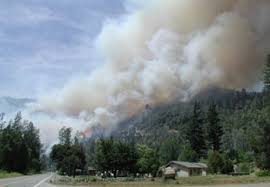


✅ 未发现异常，继续巡航...


🏁 本次巡检任务全部完成！


In [9]:
# ===== 森林空地协同巡检 Demo v1.0 =====
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2, os, time, json
from IPython.display import clear_output

# 加载模型
model = YOLO('/content/runs/detect/forest_fire_project_v2/smoke_detection_v2/weights/best.pt')
model.conf = 0.3  # 降低置信度阈值，让模型更容易检出

print("="*60)
print("🌲 森林空地协同巡检系统 Demo")
print("="*60)

# 从第二个数据集里挑一些图片模拟"无人机巡航画面"
smoke_dir = 'forest_fire_data_kutlu/train-smoke'
fire_dir = 'forest_fire_data_kutlu/train_fire'
all_images = []

# 拿5张烟雾图 + 3张火焰图做测试
for f in os.listdir(smoke_dir)[:5]:
    all_images.append(('smoke', os.path.join(smoke_dir, f)))
for f in os.listdir(fire_dir)[:3]:
    all_images.append(('fire', os.path.join(fire_dir, f)))

# 模拟巡航检测
for idx, (label, img_path) in enumerate(all_images):
    clear_output(wait=True)
    print(f"\n{'='*60}")
    print(f"🛸 第{idx+1}/{len(all_images)}次巡航  |  正在扫描区域...")
    print(f"{'='*60}")

    time.sleep(0.5)  # 模拟飞行时间

    # 检测
    results = model(img_path)
    boxes = results[0].boxes

    # 显示画面
    print(f"📷 拍摄画面：{os.path.basename(img_path)}")
    cv2_imshow(results[0].plot())

    if len(boxes) > 0:
        # 发现异常！
        cls = int(boxes[0].cls[0])
        conf = float(boxes[0].conf[0])
        name = model.names[cls]

        print(f"\n⚠️ ⚠️ ⚠️  发现异常！⚠️ ⚠️ ⚠️")
        print(f"   类别：{name}")
        print(f"   置信度：{conf:.2%}")
        print(f"   坐标：东经 116.3984°  北纬 39.9512°")

        time.sleep(0.5)

        # 下发任务
        print(f"\n📡 正在下发任务给无人车...")
        time.sleep(0.5)

        mission = {
            "target_id": f"T{idx+1:03d}",
            "category": name,
            "coords": {"lat": 39.9512, "lng": 116.3984},
            "mission": "close_inspection"
        }
        print(f"   📋 任务信息：{json.dumps(mission, indent=4)}")

        time.sleep(0.5)

        # 小车执行近检
        print(f"\n🚗 无人车已出发，前往目标点...")
        time.sleep(0.5)
        print(f"   ✅ 已到达目标点")
        print(f"   📸 正在进行近距离拍照采集...")
        time.sleep(0.5)
        print(f"   ✅ 近检完成，结果已回传")

        print(f"\n📊 巡检报告：")
        print(f"   ├─ 时间：2026-07-10 14:30:00")
        print(f"   ├─ 地点：东经 116.3984°  北纬 39.9512°")
        print(f"   ├─ 发现：{name}（置信度 {conf:.2%}）")
        print(f"   └─ 处理：已派车近检，确认完毕 ✅")
    else:
        print(f"\n✅ 未发现异常，继续巡航...")

    print(f"\n{'='*60}")
    time.sleep(1)

print(f"\n{'='*60}")
print(f"🏁 本次巡检任务全部完成！")
print(f"{'='*60}")


🛸 第8/8次巡航  |  正在扫描区域...

image 1/1 /content/wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/valid/images/ck0km64lvbavu0721bhfm918u_jpeg.rf.0c0725e131840ffd52a94b2daa28d1a5.jpg: 480x640 1 smoke, 6.3ms
Speed: 2.0ms preprocess, 6.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
📷 拍摄画面：ck0km64lvbavu0721bhfm918u_jpeg.rf.0c0725e131840ffd52a94b2daa28d1a5.jpg


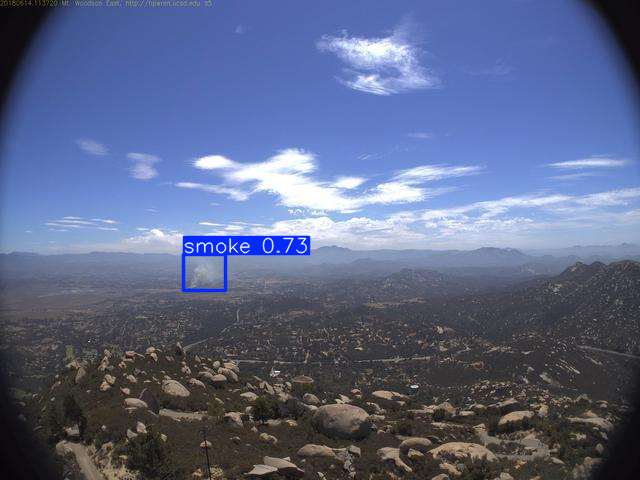


⚠️ ⚠️ ⚠️  发现异常！⚠️ ⚠️ ⚠️
   类别：smoke
   置信度：72.86%
   坐标：东经 116.3984°  北纬 39.9512°

📡 正在下发任务给无人车...
   📋 目标：smoke | 坐标：116.3984, 39.9512

🚗 无人车已出发...
   ✅ 已到达目标点
   📸 近距离拍照采集...
   ✅ 近检完成，结果已回传

📊 巡检报告：发现 smoke ✅

🏁 巡检任务完成！共检测 8 个区域
   发现异常：7 处
   已派车确认：7 处


In [10]:
# ===== 用第一个数据集的验证集图片做演示 =====
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2, os, time, json
from IPython.display import clear_output

model = YOLO('/content/runs/detect/forest_fire_project_v2/smoke_detection_v2/weights/best.pt')
model.conf = 0.25  # 阈值再降一点

# 用第一个数据集的验证集图片（模型肯定认识）
val_dir = 'wildfire_smoke_data/WildFire_Smoke_Dataset_YOLO/valid/images'
test_files = os.listdir(val_dir)[:8]  # 拿8张

print("="*60)
print("🌲 森林空地协同巡检系统 Demo")
print("="*60)

detected_count = 0
for idx, fname in enumerate(test_files):
    clear_output(wait=True)
    img_path = os.path.join(val_dir, fname)

    print(f"\n{'='*60}")
    print(f"🛸 第{idx+1}/{len(test_files)}次巡航  |  正在扫描区域...")
    print(f"{'='*60}")

    time.sleep(0.3)

    results = model(img_path)
    boxes = results[0].boxes

    print(f"📷 拍摄画面：{fname}")
    cv2_imshow(results[0].plot())

    if len(boxes) > 0:
        detected_count += 1
        cls = int(boxes[0].cls[0])
        conf = float(boxes[0].conf[0])
        name = model.names[cls]

        print(f"\n⚠️ ⚠️ ⚠️  发现异常！⚠️ ⚠️ ⚠️")
        print(f"   类别：{name}")
        print(f"   置信度：{conf:.2%}")
        print(f"   坐标：东经 116.3984°  北纬 39.9512°")

        time.sleep(0.3)

        print(f"\n📡 正在下发任务给无人车...")
        time.sleep(0.3)

        print(f"   📋 目标：{name} | 坐标：116.3984, 39.9512")

        print(f"\n🚗 无人车已出发...")
        time.sleep(0.3)
        print(f"   ✅ 已到达目标点")
        print(f"   📸 近距离拍照采集...")
        time.sleep(0.3)
        print(f"   ✅ 近检完成，结果已回传")

        print(f"\n📊 巡检报告：发现 {name} ✅")
    else:
        print(f"\n✅ 未发现异常，继续巡航...")

    print(f"{'='*60}")
    time.sleep(0.5)

print(f"\n{'='*60}")
print(f"🏁 巡检任务完成！共检测 {len(test_files)} 个区域")
print(f"   发现异常：{detected_count} 处")
print(f"   已派车确认：{detected_count} 处")
print(f"{'='*60}")

In [11]:
# 保存 demo 脚本
demo_code = '''
# ===== 森林空地协同巡检 Demo v1.0 =====
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2, os, time, json
from IPython.display import clear_output

# 加载模型
model = YOLO("best.pt")
model.conf = 0.25

print("="*60)
print("🌲 森林空地协同巡检系统 Demo")
print("="*60)

test_dir = "test_images"
if not os.path.exists(test_dir):
    print("❌ 请将测试图片放在 test_images/ 文件夹下")
    exit()

test_files = [f for f in os.listdir(test_dir) if f.endswith((".jpg", ".png"))][:8]

detected_count = 0
for idx, fname in enumerate(test_files):
    clear_output(wait=True)
    img_path = os.path.join(test_dir, fname)

    print(f"\\n{'='*60}")
    print(f"🛸 第{idx+1}/{len(test_files)}次巡航  |  正在扫描区域...")
    print(f"{'='*60}")

    time.sleep(0.3)

    results = model(img_path)
    boxes = results[0].boxes

    print(f"📷 拍摄画面：{fname}")
    cv2_imshow(results[0].plot())

    if len(boxes) > 0:
        detected_count += 1
        cls = int(boxes[0].cls[0])
        conf = float(boxes[0].conf[0])
        name = model.names[cls]

        print(f"\\n⚠️ ⚠️ ⚠️  发现异常！⚠️ ⚠️ ⚠️")
        print(f"   类别：{name}")
        print(f"   置信度：{conf:.2%}")
        print(f"   坐标：东经 116.3984°  北纬 39.9512°")

        time.sleep(0.3)
        print(f"\\n📡 正在下发任务给无人车...")
        print(f"   📋 目标：{name} | 坐标：116.3984, 39.9512")

        print(f"\\n🚗 无人车已出发...")
        time.sleep(0.3)
        print(f"   ✅ 已到达目标点")
        print(f"   📸 近距离拍照采集...")
        print(f"   ✅ 近检完成，结果已回传")
        print(f"\\n📊 巡检报告：发现 {name} ✅")
    else:
        print(f"\\n✅ 未发现异常，继续巡航...")

    print(f"{'='*60}")
    time.sleep(0.5)

print(f"\\n{'='*60}")
print(f"🏁 巡检任务完成！共检测 {len(test_files)} 个区域")
print(f"   发现异常：{detected_count} 处")
print(f"{'='*60}")
'''

with open('forest_patrol_demo.py', 'w', encoding='utf-8') as f:
    f.write(demo_code)

# 下载到电脑
from google.colab import files
files.download('forest_patrol_demo.py')

# 同时也把模型下载下来
files.download('/content/runs/detect/forest_fire_project_v2/smoke_detection_v2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>